# run_beta_compute.ipynb
This is meant to be the file that generates results for first beta paper

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import importlib

import beta_compute

from beta_compute import BetaEstimator
importlib.reload(beta_compute)
from beta_compute import BetaEstimator
from tqdm import trange

# import inspect
import pickle as pkl
import os
import time
# import mapping_tools as mt
import string

from obspy import read_inventory

# import Client
from obspy.clients.fdsn.client import Client
# import UTCDateTime
from obspy.core.utcdatetime import UTCDateTime

In [2]:
def boxplot(x, y, xbins, ax=None, color='r', **kwargs):

    if ax is None: ax = plt.gca()
    boxprops = dict(color=color)
    medianprops = dict(color=color, linewidth=2)
    whiskerprops = dict(color=color)
    capprops = dict(color=color)

    if type(x) is list: x = np.array(x)
    if type(y) is list: y = np.array(y)

    # toss out values of x, y where x is outside xbins bounds?
    
    inds = np.digitize(x, bins=xbins) - 1

    xmids = (xbins[1:] + xbins[:-1]) / 2

    xmids = xmids[np.unique(inds)]

    xwidth = xbins[1]-xbins[0]
    
    # get data in proper format for boxplot. This forms a sequence of 1D
    # arrays
    X = [y[inds==i] for i in np.unique(inds)]

    keys = kwargs.keys()
    if 'positions' not in keys: kwargs = {**kwargs, 'positions': xmids}
    if 'manage_ticks' not in keys: kwargs = {**kwargs, 'manage_ticks': False}
    if 'widths' not in keys: kwargs = {**kwargs, 'widths': xwidth*0.8}
    if 'sym' not in keys: kwargs = {**kwargs, 'sym': ''}
    if 'whis' not in keys: kwargs = {**kwargs, 'whis': (5, 95)}

    if 'boxprops' not in keys: kwargs = {**kwargs, 'boxprops': boxprops}
    if 'medianprops' not in keys: kwargs = {**kwargs, 'medianprops': medianprops}
    if 'whiskerprops' not in keys: kwargs = {**kwargs, 'whiskerprops': whiskerprops}
    if 'capprops' not in keys: kwargs = {**kwargs, 'capprops': capprops}

    out = ax.boxplot(X, **kwargs)

    return out

## Program parameters

In [3]:

# Required signal-to-noise ratio
stn_req = 3.0

# Signal-to-noise ratio testing band (Hz)
stn_band = (2.667, 6.0)

f_nyquist = 50.0

# Set paths
p_results_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/p_results/"
s_results_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/s_results/"
p_spectra_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/spectra/p_spectra.pkl"
s_spectra_path = "/Users/ivandevert/projects/spectral_falloff_ratio/data/spectra/s_spectra.pkl"
paper_figure_dir = "/Users/ivandevert/Documents/papers/high_freq_ratio/paper_name_pre_submission/figs/"
inv_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/inv/"

# Location of earthquake catalog containing stress drop estimates
delsig_p_catalog_path = "/Users/ivandevert/projects/ridgecrest2019_prev/comparisons/p_s_comparison/final/ridgecrest_stressdrop_p.txt"
delsig_s_catalog_path = "/Users/ivandevert/projects/ridgecrest2019_prev/comparisons/p_s_comparison/final/ridgecrest_stressdrop_s.txt"


# Make output directories if they don't exist
for pth in [p_results_dir, s_results_dir, paper_figure_dir, inv_dir]:
    if not os.path.exists(pth): os.makedirs(pth)

# Make sure spectra files exist
assert os.path.exists(p_spectra_path), f"p_spectra.pkl not found at {p_spectra_path}"
# assert os.path.exists(s_spectra_path), f"s_spectra.pkl not found at {s_spectra_path}"

In [4]:
# Load P-wave spectra
print("Loading P-wave spectra...", end='')
t0 = time.time()
full_df_p = pd.read_pickle(p_spectra_path)
print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(full_df_p):,} records.")

# Remove rows with irrelevant directions
print("Removing directions other than Z...", end='')
t0 = time.time()
filtered_df = full_df_p.copy()
filtered_df['direction'] = filtered_df['stid'].str[-1:]
filtered_df = filtered_df[filtered_df['direction'] == 'Z'].reset_index(drop=True)
filtered_df = filtered_df.drop('direction', axis=1)
print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(filtered_df):,} records remaining.")


# Get inventories if they do not exist
all_stids = full_df_p['stid'].unique()
# check if inventories exist
iris_client = Client("IRIS")
scedc_client = Client("SCEDC")

starttime = UTCDateTime("2019-07-01")
endtime = UTCDateTime("2019-07-16")

print("Downloading inventories...", end='')
for i in trange(len(all_stids)):
    stid = all_stids[i]
    if not os.path.exists(f"{inv_dir}{stid}.xml"):


        net, sta, loc, chan = stid.split('.')
        try:
            inventory = iris_client.get_stations(
                network=net, station=sta, location=loc, channel=chan,
                starttime=starttime, endtime=endtime, level="response",
                filename=f"{inv_dir}{stid}.xml",
                format="xml")
        except:
            try:
                inventory = scedc_client.get_stations(
                    network=net, station=sta, location=loc, channel=chan,
                    starttime=starttime, endtime=endtime, level="response",
                    filename=f"{inv_dir}{stid}.xml",
                    format="xml")
            except:
                print("Error with ", stid)
print(f"Done. t = {time.time()-t0:,.2f} seconds.")

# Make a copy
df_p = filtered_df.copy()

# Make the frequency array (assumed to be the same for all records)
nf = len(df_p['s2'].values[0])
f = np.linspace(0, f_nyquist, nf)

# Filter out low-STN records
print("Filtering out low-STN records...", end='')
t0 = time.time()
stn_i1 = np.argmin(np.abs(f - stn_band[0]))
stn_i2 = np.argmin(np.abs(f - stn_band[1]))

spectra = df_p[['s2']].values
spectra = np.stack(spectra.flatten()).astype(float)

noise = df_p[['s1']].values
noise = np.stack(noise.flatten()).astype(float)

# Compute STN
df_p['stn'] = np.median(spectra[:, stn_i1:stn_i2+1], axis=1) / np.median(noise[:, stn_i1:stn_i2+1], axis=1)

# Drop records with low STN
df_p = df_p[df_p['stn'] > stn_req].reset_index(drop=True)
print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(df_p):,} records remaining.")

# # Construct response dataframe
# print("Loading station responses...", end='')
# dt = 1 / (2.0*f_nyquist)
# nfft = (len(f)-1)*2
# stids = df_p['stid'].unique()
# st_list = []
# resp_list = []
# for i in range(len(stids)):
#     stid = stids[i]

#     resp = read_inventory(f"{inv_dir}{stid}.xml")[0][0][0].response
#     r1, _ = resp.get_evalresp_response(t_samp=dt, nfft=nfft, output="DISP", start_stage=None, end_stage=None)
#     r1[0] = r1[1] # fudge first point to avoid division by zero

#     st_list.append(stid)
#     resp_list.append(np.abs(r1))
# df_resp = pd.DataFrame({'stid': st_list, 'resp': resp_list})
# print(f"Done.")

# # Correct signal to displacement and remove response
# print("Correcting spectra to displacement...", end='')
# t0 = time.time()

# df_p = pd.merge(df_p, df_resp, how='left', on='stid')
# df_p['s2'] = df_p['s2'] / df_p['resp']
# df_p = df_p.drop('resp', axis=1)


p_spectra = df_p[['s2']].values
p_spectra = np.stack(p_spectra.flatten()).astype(float)
print(f"Done. t = {time.time()-t0:,.2f} seconds.")


### OLD WAY
# # Correct signal to displacement
# print("Correcting spectra to displacement...", end='')
# t0 = time.time()
# spectra = df_p[['s2']].values
# spectra = np.stack(spectra.flatten()).astype(float)

# # this is correct, as long as input spectra are native units (HH* = velocity, HN* = acceleration)
# # could be more efficient though
# f_corr = np.copy(f)
# f_corr[0] = f_corr[1] / 2 # fudge first point to avoid division by zero
# df_p['units'] = df_p['stid'].str[-2]
# powers = np.zeros(len(df_p), dtype=int)
# powers[df_p['units'] == 'N'] = -2
# powers[df_p['units'] == 'H'] = -1
# powers = np.tile(powers[:, np.newaxis], (1, nf))
# corr = (2*np.pi*f_corr)**powers
# df_p.drop(columns=['units'], inplace=True)

# p_spectra = spectra * corr
# df_p['s2'] = list(spectra)

# Drop unnecessary columns
df_p.drop(columns=['s1'], inplace=True)

print(f"Done. t = {time.time()-t0:,.2f} seconds.")
print("------------------------------------------------")
print(f"Number of original records: {len(filtered_df):,}")
print(f"Number of final records: {len(df_p):,}")
print(f"\nNumber of original events: {len(filtered_df['event_id'].unique()):,}")
print(f"Number of final events: {len(df_p['event_id'].unique()):,}")


Loading P-wave spectra...Done. t = 29.58 seconds, 2,681,993 records.
Removing directions other than Z...Done. t = 2.89 seconds, 943,517 records remaining.

100%|██████████| 524/524 [00:01<00:00, 505.39it/s] 

Error with  NP.5480..EHZ
Done. t = 4.76 seconds.


Filtering out low-STN records...Done. t = 13.25 seconds, 313,783 records remaining.
Done. t = 13.94 seconds.
Done. t = 13.96 seconds.
------------------------------------------------
Number of original records: 943,517
Number of final records: 313,783

Number of original events: 12,935
Number of final events: 12,684


In [5]:
# N = 14

# plt.figure()
# plt.loglog(f, df_p_resp['s2'].values[N], c='grey')
# plt.loglog(f, df_p_resp['s2_corr'].values[N], c='k')
# plt.title(f"Station {df_p_resp['stid'].values[N]}")
# plt.axvline(40)
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Response')
# plt.show()

In [6]:

importlib.reload(beta_compute)
from beta_compute import BetaEstimator

p_results = BetaEstimator(metadata_df=df_p, spectra=p_spectra, f=f, save_dir=p_results_dir)
p_results = p_results.compute(recompute=False)

p_results.save_fwf()

# p_results = p_results.compute(recompute=True)
# p_results = p_results.estimate_kappa0(fc_fixed=30, )

Initializing BetaEstimator
--------------------------
Renamed column event_id to event_name
Renamed column stid to station_name

METADATA INFORMATION
----------------------------
Events:   12,684
Stations: 169
Records:  313,783

FREQUENCY ARRAY INFORMATION
----------------------------
Frequency array ranges from 0.00 to 50.00 Hz with 76 elements (df = 0.667 Hz). 
Desired | Actual low-frequency band:     1.000 -  5.000 Hz |   1.333 -  5.333 Hz
Desired | Actual high-frequency band:   15.000 - 22.000 Hz |  15.333 - 22.000 Hz

CALIBRATION INFORMATION
----------------------------
Calibration range:   M 1.40 to 1.60
Calibration events:  1,724 (13.59%)
Calibration records: 33,744 (10.75%)

STATUS:
Data loaded successfully. Run 'compute()' to continue.
------------------------------------------------------
Same parameters. Skipping computation.


# S-wave computation

In [8]:
# Load S-wave spectra
print("Loading S-wave spectra...", end='')
t0 = time.time()
full_df_s = pd.read_pickle(s_spectra_path)
print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(full_df_s):,} records.")

# Remove rows with irrelevant directions
print("Removing directions other than N, E, 1, or 2...", end='')
dirs = ['N', 'E', '1', '2']
t0 = time.time()
filtered_df = full_df_s.copy()
filtered_df['direction'] = filtered_df['stid'].str[-1:]
keep = [True if el in dirs else False for el in filtered_df['direction'].values]
filtered_df = filtered_df[keep].reset_index(drop=True)
filtered_df = filtered_df.drop('direction', axis=1)
print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(filtered_df):,} records remaining.")


# Make a copy
df_s = filtered_df.copy()

# Make the frequency array (assumed to be the same for all records)
nf = len(df_s['s2'].values[0])
f = np.linspace(0, f_nyquist, nf)

# Filter out low-STN records
print("Filtering out low-STN records...", end='')
t0 = time.time()
stn_i1 = np.argmin(np.abs(f - stn_band[0]))
stn_i2 = np.argmin(np.abs(f - stn_band[1]))

spectra = df_s[['s2']].values
spectra = np.stack(spectra.flatten()).astype(float)

noise = df_s[['s1']].values
noise = np.stack(noise.flatten()).astype(float)

# Compute STN
df_s['stn'] = np.median(spectra[:, stn_i1:stn_i2+1], axis=1) / np.median(noise[:, stn_i1:stn_i2+1], axis=1)

# Drop records with low STN
df_s = df_s[df_s['stn'] > stn_req].reset_index(drop=True)
print(f"Done. t = {time.time()-t0:,.2f} seconds, {len(df_s):,} records remaining.")

# Correct signal to displacement
print("Correcting spectra to displacement...", end='')
t0 = time.time()
spectra = df_s[['s2']].values
spectra = np.stack(spectra.flatten()).astype(float)

# this is correct, as long as input spectra are native units (HH* = velocity, HN* = acceleration)
# could be more efficient though
# f_corr = np.copy(f)
# f_corr[0] = f_corr[1] / 2 # fudge first point to avoid division by zero
# df_s['units'] = df_s['stid'].str[-2]
# powers = np.zeros(len(df_s), dtype=int)
# powers[df_s['units'] == 'N'] = -2
# powers[df_s['units'] == 'H'] = -1
# powers = np.tile(powers[:, np.newaxis], (1, nf))
# corr = (2*np.pi*f_corr)**powers
# df_s.drop(columns=['units'], inplace=True)

s_spectra = spectra #* corr
df_s['s2'] = list(spectra)

# Drop unnecessary columns
df_s.drop(columns=['s1'], inplace=True)

print(f"Done. t = {time.time()-t0:,.2f} seconds.")
print("------------------------------------------------")
print(f"Number of original records: {len(filtered_df):,}")
print(f"Number of final records: {len(df_s):,}")
print(f"\nNumber of original events: {len(filtered_df['event_id'].unique()):,}")
print(f"Number of final events: {len(df_s['event_id'].unique()):,}")

Loading S-wave spectra...Done. t = 45.74 seconds, 2,856,948 records.
Removing directions other than N, E, 1, or 2...Done. t = 7.78 seconds, 1,878,228 records remaining.
Filtering out low-STN records...Done. t = 31.80 seconds, 727,133 records remaining.
Correcting spectra to displacement...Done. t = 1.90 seconds.
------------------------------------------------
Number of original records: 1,878,228
Number of final records: 727,133

Number of original events: 12,934
Number of final events: 12,896


In [9]:

importlib.reload(beta_compute)
from beta_compute import BetaEstimator

s_results = BetaEstimator(metadata_df=df_s, spectra=s_spectra, f=f, calib_mag_range=(1.9, 2.1), save_dir=s_results_dir)
s_results = s_results.compute(recompute=False)
# s_results = s_results.compute(recompute=True)
# s_results = s_results.estimate_kappa0(fc_fixed=30, )

Initializing BetaEstimator
--------------------------
Renamed column event_id to event_name
Renamed column stid to station_name

METADATA INFORMATION
----------------------------
Events:   12,896
Stations: 313
Records:  727,133

FREQUENCY ARRAY INFORMATION
----------------------------
Frequency array ranges from 0.00 to 50.00 Hz with 76 elements (df = 0.667 Hz). 
Desired | Actual low-frequency band:     1.000 -  5.000 Hz |   1.333 -  5.333 Hz
Desired | Actual high-frequency band:   15.000 - 22.000 Hz |  15.333 - 22.000 Hz

CALIBRATION INFORMATION
----------------------------
Calibration range:   M 1.90 to 2.10
Calibration events:  1,123 (8.71%)
Calibration records: 74,661 (10.27%)

STATUS:
Data loaded successfully. Run 'compute()' to continue.
------------------------------------------------------
Same parameters. Skipping computation.


In [10]:
len(p_results.metadata_ev)

n1 = 1
n2 = 99

# print the n1 and n2 percentile values of dlogbeta_corr
print(f"P-waves: n={len(p_results.metadata_ev)}")
print(f"{n1}-th percentile: {np.percentile(p_results.metadata_ev['dlogbeta_corr'].values, n1):.4f}")
print(f"{n2}-th percentile: {np.percentile(p_results.metadata_ev['dlogbeta_corr'].values, n2):.4f}")

# same for s-waves
print(f"S-waves: n={len(s_results.metadata_ev)}")
print(f"{n1}-th percentile: {np.percentile(s_results.metadata_ev['dlogbeta'].values, n1):.4f}")
print(f"{n2}-th percentile: {np.percentile(s_results.metadata_ev['dlogbeta'].values, n2):.4f}")

P-waves: n=11429
1-th percentile: -0.4843
99-th percentile: 0.3310
S-waves: n=11584
1-th percentile: -0.8039
99-th percentile: 0.4581


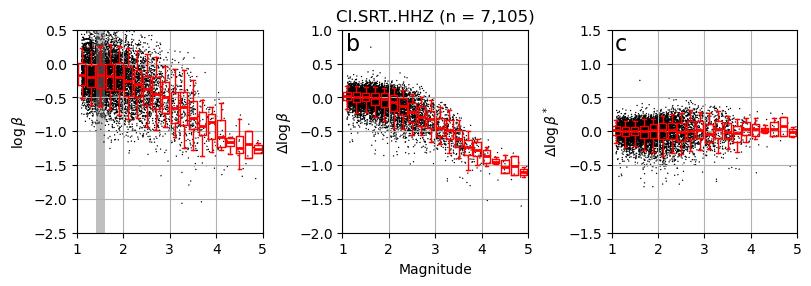

In [11]:
# Corrections for a single example station
from matplotlib.patches import Rectangle
import string

# for i, row in df_sta.iterrows():
#     print(i, row['station_name'], len(row['event_name']))

df_sta = p_results.metadata_st
df_calib = p_results.metadata_calib

stname = "CI.SRT..HHZ"
phase = "p"
# find index of the station of interest
stind_plot = df_sta[df_sta['station_name'] == stname].index[0]
df_plot = df_sta.iloc[stind_plot]

dx = 0.2
edges = np.arange(1.0, 7.3, dx)
ylim = np.array([-1.5, 1.5])

calib_mag_range = p_results.calib_mag_range

df_c = df_calib[df_calib['station_name']==stname]

fig, axs = plt.subplots(1,3, figsize=[8,2.75], sharex=True, sharey=False, layout='constrained')
# fig, axs = plt.subplots(1,3, figsize=[8,3], sharex=True, sharey=False, layout='constrained')
axs[0].scatter(df_plot['emag'], df_plot['logbeta'], c='k', s=1, edgecolors='none', label=r'$\log\beta$')
axs[0].scatter(df_c['emag'], df_c['logbeta'], c='k', s=1, edgecolors='none')

axs[1].scatter(df_plot['emag'], df_plot['dlogbeta'], c='k', s=1, edgecolors='none', label=r'$\Delta\log\beta$')
axs[2].scatter(df_plot['emag'], df_plot['dlogbeta_corr'], c='k', s=1, edgecolors='none', label=r'$\Delta\log\beta^*$')

boxplot(df_plot['emag'], df_plot['logbeta'], xbins=edges, ax=axs[0], color='r')
boxplot(df_c['emag'], df_c['logbeta'], xbins=edges, ax=axs[0], color='r')
boxplot(df_plot['emag'], df_plot['dlogbeta'], xbins=edges, ax=axs[1], color='r')
boxplot(df_plot['emag'], df_plot['dlogbeta_corr'], xbins=edges, ax=axs[2], color='r')

# shaded rectangle around calibration events range
axs[0].add_patch(Rectangle((calib_mag_range[0], -4.5), calib_mag_range[1]-calib_mag_range[0], 9, fill=True, facecolor='gray', alpha=0.5, edgecolor='none'))

axs[0].set_xlim([1.0, 5])
axs[0].set_ylim(ylim - 1)
axs[1].set_ylim(ylim - 0.5)
axs[2].set_ylim(ylim)
axs[1].set_xlabel('Magnitude')
axs[0].set_ylabel(r'$\log\beta$')
axs[1].set_ylabel(r'$\Delta\log\beta$')
axs[2].set_ylabel(r'$\Delta\log\beta^*$')
axs[1].set_title(f'{stname} (n = {len(df_plot['emag']):,.0f})')
# axs[0].legend()
# axs[1].legend()
# axs[2].legend()
axs[0].grid(True)
axs[1].grid(True)
axs[2].grid(True)

# panel labels
for n, axes in enumerate(axs):
    axes.text(0.019, 0.90, string.ascii_lowercase[n], transform=axes.transAxes, 
        size=16)
        
# plt.savefig(paper_figure_dir + f"p_corrections.pdf", bbox_inches='tight')
plt.show()

In [12]:
import utm

P = p_results.metadata_ev[p_results.ev_dep]
S = s_results.metadata_ev[s_results.ev_dep]

df = pd.merge(P, S, how='outer', on=['event_name', 'elat', 'elon', 'edep', 'emag', 'ex', 'ey'], suffixes=('_p', '_s'))


# read in past results
cnames = ["event_name", "eyr", "emon", "eday", "ehr", "emn", "esc", "emag", 
          "elat", "elon", "edep", "nst", "negf", "fc", "delsig"]

ds_p = pd.read_fwf(delsig_p_catalog_path, names=cnames)[['event_name', 'delsig', 'fc']]
ds_s = pd.read_fwf(delsig_s_catalog_path, names=cnames)[['event_name', 'delsig', 'fc']]
ds = pd.merge(ds_p, ds_s, how='outer', on='event_name', suffixes=('_p', '_s')) # tested, works
print(f"{len(ds):,} unique events with stress drop estimates from Vandevert et al. 2024")

df = pd.merge(df, ds, how='left', on='event_name')

ds_p = pd.read_fwf(delsig_p_catalog_path, names=cnames)
ds_s = pd.read_fwf(delsig_s_catalog_path, names=cnames)

# This fixes a bug where df doesn't groupby correctly when delsig is np.nan
df.loc[np.isnan(df['delsig_p']), 'delsig_p'] = 0
df.loc[np.isnan(df['delsig_s']), 'delsig_s'] = 0
df.loc[np.isnan(df['fc_p']), 'fc_p'] = 0
df.loc[np.isnan(df['fc_s']), 'fc_s'] = 0

ds_p['ex'], ds_p['ey'], zn, zl = utm.from_latlon(
    ds_p['elat'].values, 
    ds_p['elon'].values
    )
ds_s['ex'], ds_s['ey'], zn, zl = utm.from_latlon(
    ds_s['elat'].values, 
    ds_s['elon'].values
    )

6,827 unique events with stress drop estimates from Vandevert et al. 2024


In [ ]:
# import matplotlib as mpl

# # filtering arrays 
# pp = np.ones(len(df), dtype=bool)
# pp[np.isnan(df['dlogbeta_p'])] = False  # remove nan values
# pp[df['dlogbeta_corr_p']==0.0] = False  # remove entries that couldn't compute dlogbeta_corr
# ss = np.ones(len(df), dtype=bool)
# ss[np.isnan(df['dlogbeta_s'])] = False
# ss[df['dlogbeta_corr_s']==0.0] = False

# clim = [-0.333, 0.333]

# cmap = mpl.cm.coolwarm.reversed()
# bounds = np.linspace(clim[0], clim[1], 7)
# cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
# smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

# df_plot = df[pp]#[df['qmag']>2]
# dataname = 'dlogbeta_corr_p'
# datatitle = r"$\Delta\log\beta^*$"

# # cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='mediancenter')

# # fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(11.2, 16), sharex=True, sharey=True, gridspec_kw={'wspace':0, 'hspace':0})
# fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 16), sharex=True, sharey=True, gridspec_kw={'wspace':0, 'hspace':0.05})


# mapout = mt.plot_map(
#     df_plot,
#     ax=ax[0,0],
#     zoom=1.05,
#     cname=dataname,
#     cnorm=cnorm,
#     smap=smap,
#     distinguish_clipped=False,
#     bgcolor=(1,1,1),

# )

# df_plot = df[ss]#[df['qmag']>2.5]
# dataname = 'dlogbeta_corr_s'
# mapout = mt.plot_map(
#     df_plot,
#     ax=ax[0,1],
#     zoom=1.05,
#     cname=dataname,
#     cnorm=cnorm,
#     smap=smap,
#     distinguish_clipped=False,
#     bgcolor=(1,1,1),

# )

# cb_ax = fig.add_axes([0.905,.5,.015,.37])
# cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
#     cax=cb_ax, extend='neither')
# smap.set_clim(clim)

# cbar.ax.set_ylabel(r"$\Delta\log\beta^*$")



# ### OLD DELSIG DATA

# clim = [1.5, 150]

# cmap = mpl.cm.coolwarm.reversed()
# bounds = np.logspace(np.log10(clim[0]), np.log10(clim[1]), 7)
# cnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither')
# smap = mpl.cm.ScalarMappable(norm=cnorm, cmap=cmap)

# df_plot = ds_p[~np.isnan(ds_p['delsig'])][ds_p['qmag']>2.0]
# dataname = 'delsig'
# datatitle = r"$\Delta\log\beta^*$"


# mapout = mt.plot_map(
#     df_plot,
#     ax=ax[1,0],
#     zoom=1.05,
#     cname=dataname,
#     cnorm=cnorm,
#     smap=smap,
#     distinguish_clipped=False,
#     bgcolor=(1,1,1),

# )

# df_plot = ds_s[~np.isnan(ds_s['delsig'])]
# df_plot = df_plot[df_plot['qmag']>2.5]
# dataname = 'delsig'
# mapout = mt.plot_map(
#     df_plot,
#     ax=ax[1,1],
#     zoom=1.05,
#     cname=dataname,
#     cnorm=cnorm,
#     smap=smap,
#     distinguish_clipped=False,
#     bgcolor=(1,1,1),

# )



# cb_ax = fig.add_axes([0.905,.12,.015,.37])
# cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
#     cax=cb_ax, extend='neither')
# smap.set_clim(clim)
# cbar.ax.set_ylabel(r"$\Delta \sigma$ (MPa)")

# for AX in ax.flatten():
#     AX.get_xaxis().set_ticks([])
#     AX.get_yaxis().set_ticks([])


# ax[0,0].annotate(r"P-wave $\Delta\log\beta^*$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
# ax[0,1].annotate(r"S-wave $\Delta\log\beta^*$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
# ax[1,0].annotate(r"P-wave $\Delta \sigma$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)
# ax[1,1].annotate(r"S-wave $\Delta \sigma$", xy=(0.02, 0.01), xycoords='axes fraction', fontsize=18)


# # panel labels
# for n, axes in enumerate(ax.flatten()):
#     axes.text(0.015, 0.95, string.ascii_lowercase[n], transform=axes.transAxes, 
#         size=20)


# # plt.savefig(f"{paper_figure_dir}map_comp.pdf", bbox_inches='tight')

# plt.show()

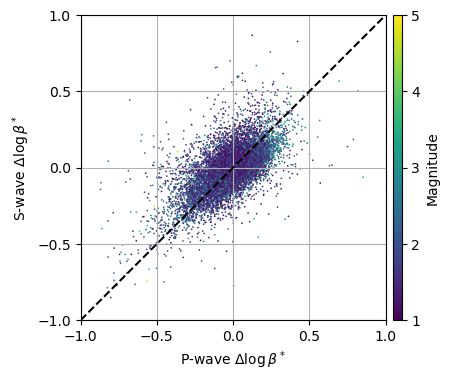

In [13]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
xlim = [-1, 1]


fig, ax = plt.subplots(1,1, figsize=(4,4), constrained_layout=True)
sc = ax.scatter(df['dlogbeta_corr_p'], df['dlogbeta_corr_s'], c=df['emag'], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)
ax.plot(xlim, xlim, c='k', linestyle='--')
ax.set_ylim(xlim)
ax.set_xlim(xlim)


ax.set_xlabel(r"P-wave $\Delta\log\beta^*$")
ax.set_ylabel(r"S-wave $\Delta\log\beta^*$")

ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.grid(True)
ax.set_aspect('equal')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=.07)

plt.colorbar(sc, cax=cax)

cax.set_ylabel('Magnitude')
cax.set_yticks([1, 2, 3, 4, 5])

# plt.savefig(f"{paper_figure_dir}PS_beta_comparison.pdf", bbox_inches='tight')

plt.show()

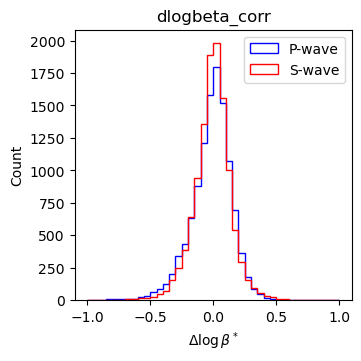

P-wave dlogbeta_corr
count    11429.000000
mean        -0.014736
std          0.160762
min         -0.961886
25%         -0.099713
50%          0.001662
75%          0.086907
max          0.852355
Name: dlogbeta_corr_p, dtype: float64
5% and 95% quantiles: 
 0.05   -0.299401
0.95    0.216743
Name: dlogbeta_corr_p, dtype: float64


S-wave dlogbeta_corr
count    11584.000000
mean        -0.007050
std          0.146149
min         -0.851950
25%         -0.084744
50%         -0.000241
75%          0.075911
max          0.868826
Name: dlogbeta_corr_s, dtype: float64
5% and 95% quantiles: 
 0.05   -0.252565
0.95    0.216490
Name: dlogbeta_corr_s, dtype: float64


In [14]:
# plot histogram of all dlogbeta_corr_p and dlogbeta_corr_s

fig, ax = plt.subplots(1,1, figsize=(3.5,3.5), constrained_layout=True)

ax.hist(df['dlogbeta_corr_p'], bins=np.arange(-1.0, 1.05, 0.05), histtype='step', label='P-wave', color='b')
ax.hist(df['dlogbeta_corr_s'], bins=np.arange(-1.0, 1.05, 0.05), histtype='step', label='S-wave', color='r')

ax.set_title(f'dlogbeta_corr')
ax.set_xlabel(r"$\Delta\log\beta^*$")
ax.set_ylabel('Count')
ax.legend()
# ax[0].set_yscale('log')
# ax[1].set_yscale('log')

plt.show()

# print stats on each quantity (mean, median, std, min, max)
print("P-wave dlogbeta_corr")
print(df['dlogbeta_corr_p'].describe())

# print 5% and 95% quantiles
print("5% and 95% quantiles: \n", df['dlogbeta_corr_p'].quantile([0.05, 0.95]))

print("\n\nS-wave dlogbeta_corr")
print(df['dlogbeta_corr_s'].describe())

# print 5% and 95% quantiles
print("5% and 95% quantiles: \n", df['dlogbeta_corr_s'].quantile([0.05, 0.95]))

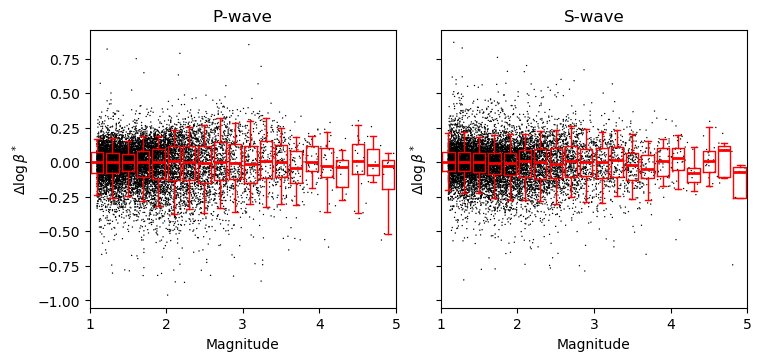

In [164]:
# plot dlogbeta_corr vs magnitude for P and S using boxplot

k1 = np.where(~np.isnan(df['dlogbeta_corr_p']))[0]
k2 = np.where(~np.isnan(df['dlogbeta_corr_s']))[0]



edges = np.arange(1.0, 7.3, 0.2)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7.5,3.5), sharey=True, constrained_layout=True)

ax1.scatter(df['emag'].values[k1], df['dlogbeta_corr_p'].values[k1], c='k', s=1, edgecolors='none')
ax2.scatter(df['emag'].values[k2], df['dlogbeta_corr_s'].values[k2], c='k', s=1, edgecolors='none')

boxplot(df['emag'].values[k1], df['dlogbeta_corr_p'].values[k1], xbins=edges, ax=ax1, color='r')
boxplot(df['emag'].values[k2], df['dlogbeta_corr_s'].values[k2], xbins=edges, ax=ax2, color='r')



ax1.set_title(f'P-wave')
ax1.set_xlabel('Magnitude')
ax1.set_ylabel(r"$\Delta\log\beta^*$")

ax2.set_title(f'S-wave')
ax2.set_xlabel('Magnitude')
ax2.set_ylabel(r"$\Delta\log\beta^*$")

ax1.set_xlim([1, 5])
ax2.set_xlim([1, 5])

plt.show()

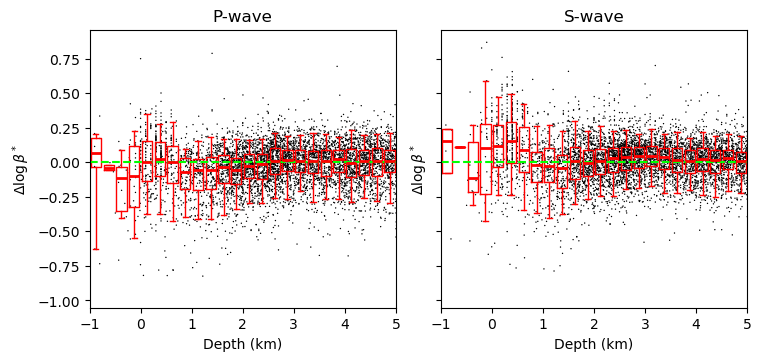

In [173]:
# plot dlogbeta_corr vs depth for P and S using boxplot

k1 = np.where(~np.isnan(df['dlogbeta_corr_p']))[0]
k2 = np.where(~np.isnan(df['dlogbeta_corr_s']))[0]



edges = np.arange(-1.0, 25, 0.25)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(7.5,3.5), sharey=True, constrained_layout=True)




ax1.scatter(df['edep'].values[k1], df['dlogbeta_corr_p'].values[k1], c='k', s=1, edgecolors='none')
ax2.scatter(df['edep'].values[k2], df['dlogbeta_corr_s'].values[k2], c='k', s=1, edgecolors='none')

boxplot(df['edep'].values[k1], df['dlogbeta_corr_p'].values[k1], xbins=edges, ax=ax1, color='r')
boxplot(df['edep'].values[k2], df['dlogbeta_corr_s'].values[k2], xbins=edges, ax=ax2, color='r')



ax1.set_title(f'P-wave')
ax1.set_xlabel('Depth (km)')
ax1.set_ylabel(r"$\Delta\log\beta^*$")

ax2.set_title(f'S-wave')
ax2.set_xlabel('Depth (km)')
ax2.set_ylabel(r"$\Delta\log\beta^*$")

ax1.axhline(0, c='lime', ls='--')
ax2.axhline(0, c='lime', ls='--')



ax1.set_xlim([-1, 5])
ax2.set_xlim([-1, 5])

plt.show()

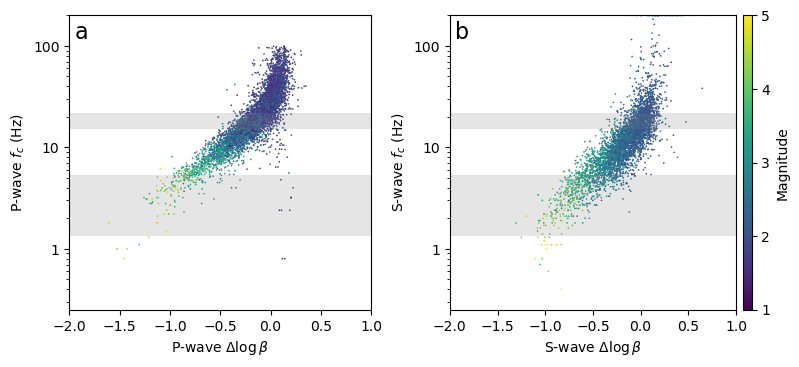

Mean, median magnitude of events with P-wave fc in high beta window: 2.07, 2.01
Mean, median magnitude of events with P-wave fc in low beta window: 3.70, 3.76
Mean, median magnitude of events with S-wave fc in high beta window: 2.23, 2.16
Mean, median magnitude of events with S-wave fc in low beta window: 3.25, 3.27


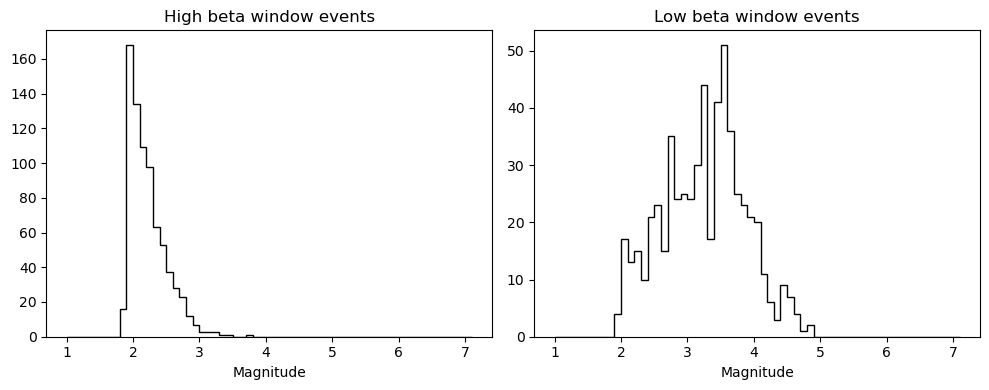

In [15]:
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable

low_beta_window_p = p_results.low_window
low_beta_window_s = s_results.low_window

high_beta_window_p = p_results.high_window
high_beta_window_s = s_results.high_window

fcylim = [10**(-0.6), 200.0]
xlim = [-2, 1]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7.5,3.5),
    layout='constrained')

# ax[0].scatter(df['dlogbeta_corr_p'], df['delsig_p'], c='k', s=3, marker='.', edgecolors='none')
# ax[1].scatter(df['dlogbeta_corr_s'], df['delsig_s'], c='k', s=3, marker='.', edgecolors='none')

sc = ax[0].scatter(df['dlogbeta_p'], df['fc_p'], c=df['emag'], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)
ax[1].scatter(df['dlogbeta_s'], df['fc_s'], c=df['emag'], s=6, marker='.', edgecolors='none', vmin=1.0, vmax=5.0)

# grey rectangle for low_beta_window_p
ax[0].add_patch(Rectangle((xlim[0], low_beta_window_p[0]), xlim[1]-xlim[0], low_beta_window_p[1]-low_beta_window_p[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))
ax[0].add_patch(Rectangle((xlim[0], high_beta_window_p[0]), xlim[1]-xlim[0], high_beta_window_p[1]-high_beta_window_p[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))

ax[1].add_patch(Rectangle((xlim[0], low_beta_window_s[0]), xlim[1]-xlim[0], low_beta_window_s[1]-low_beta_window_s[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))
ax[1].add_patch(Rectangle((xlim[0], high_beta_window_s[0]), xlim[1]-xlim[0], high_beta_window_s[1]-high_beta_window_s[0], fill=True, facecolor='gray', alpha=0.2, edgecolor='none'))


ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_ylim(fcylim)
ax[1].set_ylim(fcylim)

ax[0].set_xlim(xlim)
ax[1].set_xlim(xlim)

ax[0].set_xlabel(r"P-wave $\Delta\log\beta$")
ax[1].set_xlabel(r"S-wave $\Delta\log\beta$")

ax[0].set_ylabel(r"P-wave $f_c$ (Hz)")
ax[1].set_ylabel(r"S-wave $f_c$ (Hz)")

ax[0].set_yticks([1, 10, 100])
ax[0].set_yticklabels([1, 10, 100])
ax[1].set_yticks([1, 10, 100])
ax[1].set_yticklabels([1, 10, 100])
# ax[0].set_yticks([0.3, 1, 3, 10, 30, 100])
# ax[0].set_yticklabels([0.3, 1, 3, 10, 30, 100])

divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="3%", pad=.07)

plt.colorbar(sc, cax=cax)
cax.set_ylabel('Magnitude')
cax.set_yticks([1, 2, 3, 4, 5])

# panel labels
for n, axes in enumerate(ax.flatten()):
    axes.text(0.019, 0.92, string.ascii_lowercase[n], transform=axes.transAxes, 
        size=16)
        
# plt.savefig(f"{paper_figure_dir}PS_beta_fc_comparison.pdf", bbox_inches='tight')
plt.show()


###
mags_high_window = df['emag'][np.logical_and(df['fc_p']>=high_beta_window_p[0], df['fc_p']<=high_beta_window_p[1])]
mags_low_window = df['emag'][np.logical_and(df['fc_p']>=low_beta_window_p[0], df['fc_p']<=low_beta_window_p[1])]

print(f"Mean, median magnitude of events with P-wave fc in high beta window: {np.mean(mags_high_window):.2f}, {np.median(mags_high_window):.2f}")
print(f"Mean, median magnitude of events with P-wave fc in low beta window: {np.mean(mags_low_window):.2f}, {np.median(mags_low_window):.2f}")


# do the same for S-wave windows
mags_high_window = df['emag'][np.logical_and(df['fc_s']>=high_beta_window_s[0], df['fc_s']<=high_beta_window_s[1])]
mags_low_window = df['emag'][np.logical_and(df['fc_s']>=low_beta_window_s[0], df['fc_s']<=low_beta_window_s[1])]

print(f"Mean, median magnitude of events with S-wave fc in high beta window: {np.mean(mags_high_window):.2f}, {np.median(mags_high_window):.2f}")
print(f"Mean, median magnitude of events with S-wave fc in low beta window: {np.mean(mags_low_window):.2f}, {np.median(mags_low_window):.2f}")

# figure showing hists of mags_high_window and mags_low_window
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(mags_high_window, bins=np.arange(1.0, 7.2, 0.1), histtype='step', edgecolor='k')
ax[1].hist(mags_low_window, bins=np.arange(1.0, 7.2, 0.1), histtype='step', edgecolor='k')

ax[0].set_xlabel('Magnitude')
ax[1].set_xlabel('Magnitude')
ax[0].set_title('High beta window events')
ax[1].set_title('Low beta window events')

plt.tight_layout()
plt.show()

In [18]:
# find events within a fc range of the outer edges of the low and high beta windows
fc_low_range = [1, 2]
fc_high_range = [20, 24]

events_low_fc = df[np.logical_and(df['fc_p']>=fc_low_range[0], df['fc_p']<=fc_low_range[1])]
events_high_fc = df[np.logical_and(df['fc_p']>=fc_high_range[0], df['fc_p']<=fc_high_range[1])]

print(f"Mean, median magnitude of events with P-wave fc in low fc range: {np.mean(events_low_fc['emag']):.2f}, {np.median(events_low_fc['emag']):.2f}")
print(f"Mean, median magnitude of events with P-wave fc in high fc range: {np.mean(events_high_fc['emag']):.2f}, {np.median(events_high_fc['emag']):.2f}")


Mean, median magnitude of events with P-wave fc in low fc range: 5.10, 4.71
Mean, median magnitude of events with P-wave fc in high fc range: 1.97, 1.92
